<h1>Quick Start

In [1]:
import pandas as pd
import pickle

# --- 1) 댓글 단위 전처리 결과 ---
comments_df = pd.read_csv('preprocessed_comments.csv', encoding='utf-8-sig')

# --- 2) 영상 단위 집계 결과 ---
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# --- 3) TF-IDF 행렬 ---
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)

# --- 4) TF-IDF Vectorizer ---
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# === 로드 확인 ===
print('=== comments_df ===')
print(f'  Shape: {comments_df.shape}')
print(f'  Columns: {list(comments_df.columns)}')
print(comments_df.head(2))

print('\n=== video_df ===')
print(f'  Shape: {video_df.shape}')
print(f'  Columns: {list(video_df.columns)}')
print(video_df.head(2))

print(f'\n=== tfidf_matrix ===')
print(f'  Type: {type(tfidf_matrix)}')
print(f'  Shape: {tfidf_matrix.shape}')

print(f'\n=== vectorizer ===')
print(f'  Type: {type(vectorizer)}')
print(f'  Feature 수: {len(vectorizer.get_feature_names_out())}')
print(f'  Feature 샘플: {list(vectorizer.get_feature_names_out()[:10])}')

=== comments_df ===
  Shape: (9466, 8)
  Columns: ['Video Title', 'Video URL', 'Likes', 'Comment', 'category', 'Comment_clean', 'lang', 'tokens_clean']
                                         Video Title  \
0  NewJeans (뉴진스) 'OMG' Official MV (Performance ...   
1  NewJeans (뉴진스) 'OMG' Official MV (Performance ...   

                                           Video URL    Likes  \
0  https://www.youtube.com/watch?v=sVTy_wmn5SU&li...  2490682   
1  https://www.youtube.com/watch?v=sVTy_wmn5SU&li...  2490682   

                                             Comment category  \
0  민희진님은 절대 ㅈㅅ 안한다고 했습니다.\r\n️️️️️️️️️️\r\n이 댓글이 ...      뉴진스   
1  뉴진스 데뷔 미룬 것도 르세라핌이 5.2에 데뷔해야해서 그런거냐ㅜ방시혁 정신 좀 차...      뉴진스   

                                       Comment_clean lang  \
0  민희진님은 절대 안한다고 했습니다 이 댓글이 삭제된다면 하이브에서 삭제하는 것입니다...   ko   
1  뉴진스 데뷔 미룬 것도 르세라핌이 5 2에 데뷔해야해서 그런거냐 방시혁 정신 좀 차...   ko   

                         tokens_clean  
0  민희진 절대 댓글 삭제 하이브 삭제 좋다 누르다 위로 올려주다  
1   뉴진스 데뷔 미루다 세라핌 데뷔 그

<h1>K-Means 모델 학습

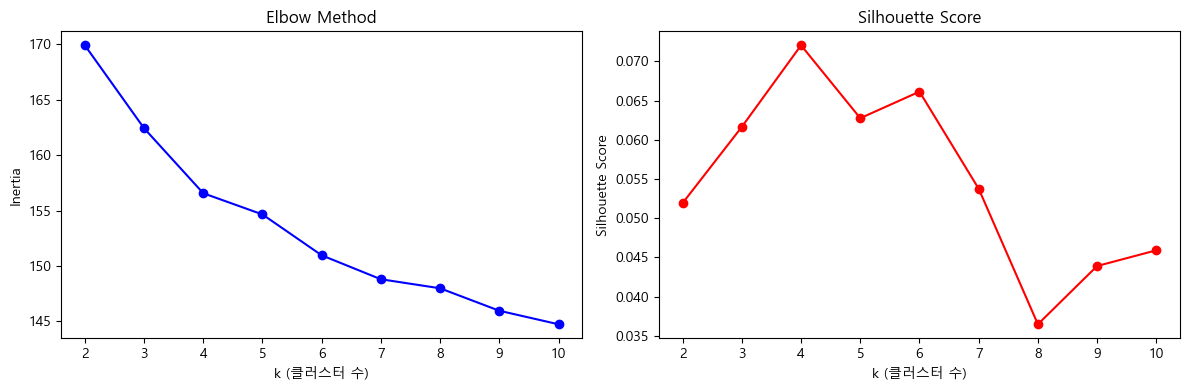

최적 k: 4
Silhouette Score: 0.0721
클러스터별 영상 수: [59 48 49 41]


In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 윈도우 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 그래프에서 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# --- Elbow Method + Silhouette Score ---
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(tfidf_matrix, km.labels_))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k (클러스터 수)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k (클러스터 수)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150)
plt.show()

# 최적 k로 최종 모델 학습 (예: k=4)
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)

print(f'최적 k: {best_k}')
print(f'Silhouette Score: {silhouette_score(tfidf_matrix, kmeans.labels_):.4f}')
print(f'클러스터별 영상 수: {np.bincount(kmeans.labels_)}')

<h1>PCA 2D 시각화로 클러스터 확인

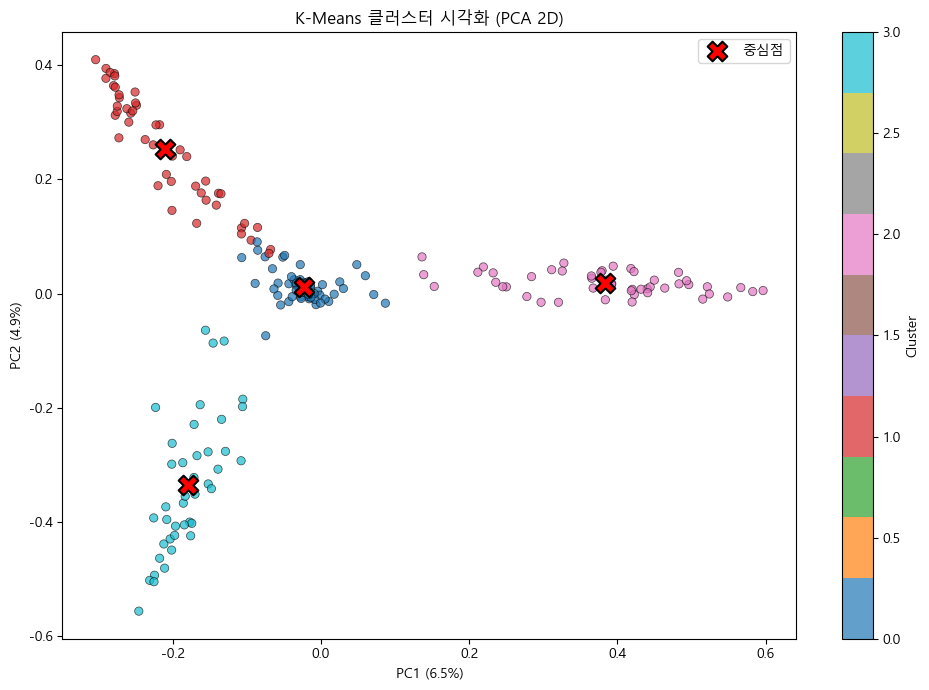

클러스터 0: 월드컵, 보다, 선수, 경기, 축구, 손흥민, 영상, 좋다, 이강인, 감독
클러스터 1: ai, 인간, 교수, 보다, 시대, 사람, 가다, 감사하다, 판사, 생각
클러스터 2: 뉴진스, newjeans, 노래, miss, new, song, never, jean, danielle, like
클러스터 3: 전쟁, 이스라엘, 이란, 미국, 네타냐후, 트럼프, 국민, 나라, 악마, 국가


In [3]:
from sklearn.decomposition import PCA

# PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

# 시각화
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=kmeans.labels_, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('K-Means 클러스터 시각화 (PCA 2D)')

# 클러스터 중심점 표시
centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='k', linewidths=1.5, label='중심점'
)
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca_visualization.png', dpi=150)
plt.show()

# 각 클러스터별 상위 키워드 확인
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

feature_names = vectorizer.get_feature_names_out()
for i in range(best_k):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[::-1][:10]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f'클러스터 {i}: {", ".join(top_words)}')

<h1>키워드 기반 클러스터 추천

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_by_cluster(keywords, top_n=5):
    """K-Means 클러스터 기반 키워드 추천

    Args:
        keywords: 검색 키워드 문자열 (공백 구분)
        top_n: 추천 영상 수
    """
    # 키워드 → TF-IDF 벡터 변환
    query_vec = vectorizer.transform([keywords])

    # 클러스터 예측
    cluster_id = kmeans.predict(query_vec)[0]

    # 해당 클러스터에 속한 영상 인덱스 추출
    cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]

    # 클러스터 내 코사인 유사도 계산
    cluster_matrix = tfidf_matrix[cluster_indices]
    similarities = cosine_similarity(query_vec, cluster_matrix).flatten()

    # 유사도 기준 정렬
    sorted_order = similarities.argsort()[::-1][:top_n]

    print(f'검색 키워드: "{keywords}"')
    print(f'할당된 클러스터: {cluster_id} (클러스터 내 영상 수: {len(cluster_indices)}개)\n')

    for rank, order_idx in enumerate(sorted_order, 1):
        video_idx = cluster_indices[order_idx]
        row = video_df.iloc[video_idx]
        print(f'{rank}. [{row["category"]}] {row["Video Title"]}')
        print(f'   유사도: {similarities[order_idx]:.4f} | 좋아요: {row["Likes"]:,} | 댓글: {row["comment_count"]}건')
        print(f'   URL: {row["Video URL"]}')
        print()

# 사용 예시
recommend_by_cluster('감동 응원 열정', top_n=5)
recommend_by_cluster('전쟁 평화 국제', top_n=3)

검색 키워드: "감동 응원 열정"
할당된 클러스터: 0 (클러스터 내 영상 수: 59개)

1. [월드컵] 26 FIFA 월드컵 가즈아! 🔥 축덕 김민경의 짜릿한 트로피 투어 현장 [썰스티] Special Ep.
   유사도: 0.0963 | 좋아요: 78 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=InhfSAfEHjM&pp=ygUJ7JuU65Oc7Lu1

2. [월드컵] 20년이 지났지만 잊을 수 없는 그 여름날! 2002 월드컵 뜨거웠던 7경기의 기억! ㅣ월드컵 메모리즈 / 14F
   유사도: 0.0873 | 좋아요: 54,773 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=I9vK5EVTt0U&pp=ygUJ7JuU65Oc7Lu1

3. [월드컵] [MBC 한일월드컵] 2002년 6월의 함성, 대~한민국
   유사도: 0.0826 | 좋아요: 28,448 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=gJuDdamvZ6M&pp=ygUJ7JuU65Oc7Lu1

4. [월드컵] 멀티골 넣고 미친 활약 보여줬던 조규성... 미 매체, “미친 경기”
   유사도: 0.0730 | 좋아요: 5,146 | 댓글: 47건
   URL: https://www.youtube.com/watch?v=U2YKyMJhT5c&pp=ygUJ7JuU65Oc7Lu1

5. [월드컵] 드라마도 이렇게는 못 쓴다...😂 경우의 수보다 중요한 건 '꺾이지 않는 마음' [카타르월드컵 H조 대한민국 vs 포르투갈]
   유사도: 0.0660 | 좋아요: 28,975 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=2iaiuOQM458&pp=ygUJ7JuU65Oc7Lu1

검색 키워드: "전쟁 평화 국제"
할당된 클러스터: 3 (클러스터 내 영상 수: 41개)

1. [이스라엘] 이스라엘 밤하늘에 쏟아진 '악마의 무기'…유

<h1>카테고리별 클러스터 분포 분석

=== 카테고리 × 클러스터 교차표 ===
cluster    0   1   2   3  All
category                     
뉴진스        1   0  49   0   50
월드컵       49   0   0   0   49
이스라엘       8   1   0  41   50
인공지능       1  47   0   0   48
All       59  48  49  41  197

=== 카테고리별 클러스터 비율 ===
cluster       0      1     2     3
category                          
뉴진스       0.020  0.000  0.98  0.00
월드컵       1.000  0.000  0.00  0.00
이스라엘      0.160  0.020  0.00  0.82
인공지능      0.021  0.979  0.00  0.00


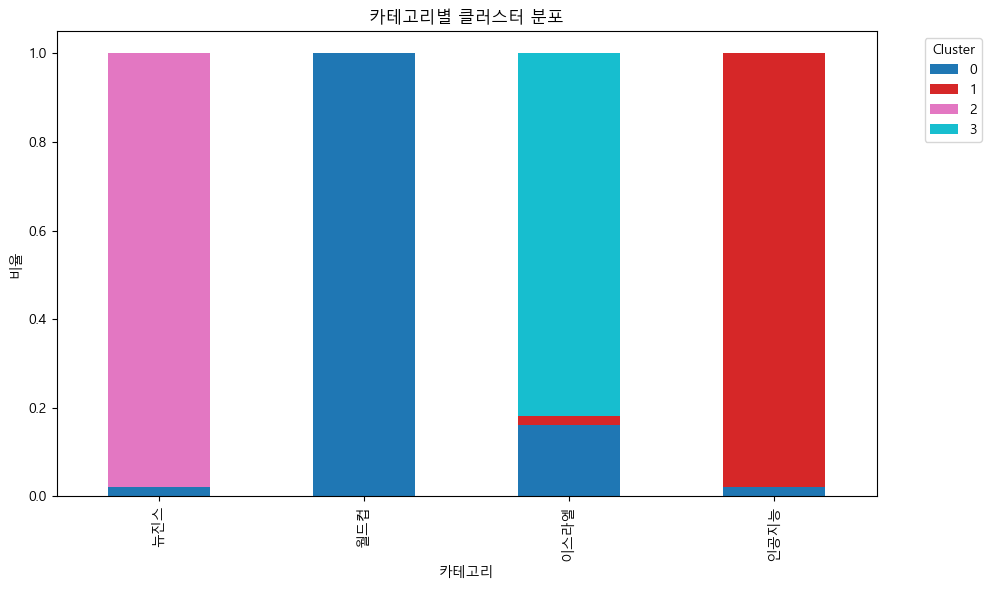

In [5]:
# 클러스터 레이블을 video_df에 추가
video_df['cluster'] = kmeans.labels_

# 교차표 생성
cross = pd.crosstab(video_df['category'], video_df['cluster'], margins=True)
print('=== 카테고리 × 클러스터 교차표 ===')
print(cross)

# 비율 교차표 (행 기준)
cross_pct = pd.crosstab(video_df['category'], video_df['cluster'], normalize='index')
print('\n=== 카테고리별 클러스터 비율 ===')
print(cross_pct.round(3))

# 시각화: 스택 바 차트
cross_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title('카테고리별 클러스터 분포')
plt.xlabel('카테고리')
plt.ylabel('비율')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('category_cluster_distribution.png', dpi=150)
plt.show()

<h1>개선된 Word2Vec 기반 모델 코드</h1>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# 0. 윈도우 환경 한글 폰트 및 시각화 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호 깨짐 방지

# ==========================================
# 1. 데이터 로드 및 전처리
# ==========================================
print("데이터를 로드하는 중...")
comments_df = pd.read_csv('preprocessed_comments.csv', encoding='utf-8-sig')
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# Word2Vec 학습을 위해 공백으로 연결된 문자열을 리스트로 변환
# 결측치(NaN)가 있을 수 있으므로 fillna('') 처리 후 split()
comments_df['tokens_list'] = comments_df['tokens_clean'].fillna('').apply(lambda x: x.split())

# ==========================================
# 2. Word2Vec 모델 학습 (실습 교재 참고)
# ==========================================
print("Word2Vec 모델 학습 중...")
# sentences: 토큰 리스트의 리스트
# vector_size: 임베딩 벡터의 차원 수 (예: 100차원)
# window: 주변 단어 고려 범위
# min_count: 최소 등장 횟수 (이하 단어는 무시)
w2v_model = Word2Vec(sentences=comments_df['tokens_list'], 
                     vector_size=100, 
                     window=5, 
                     min_count=2, 
                     workers=4)
print(f"학습 완료! 단어 사전(Vocabulary) 크기: {len(w2v_model.wv)}")

# ==========================================
# 3. 영상 문서 벡터화 (Average Embedding)
# ==========================================
def get_document_vector(tokens_str, model):
    """
    단어 토큰 문자열을 받아 Word2Vec 벡터들의 평균(Average Embedding)을 반환하는 함수
    """
    words = str(tokens_str).split()
    # Word2Vec 단어 사전에 존재하는 단어만 필터링
    valid_words = [word for word in words if word in model.wv.key_to_index]
    
    if not valid_words:
        # 유효한 단어가 하나도 없으면 0벡터 반환
        return np.zeros(model.vector_size)
    
    # 유효한 단어들의 임베딩 벡터 리스트 생성 후 평균(mean) 계산
    vectors = [model.wv[word] for word in valid_words]
    return np.mean(vectors, axis=0)

print("197개 영상별 Average Embedding 벡터 생성 중...")
# video_df의 'all_tokens' 컬럼을 이용하여 각 영상의 평균 벡터 생성
video_df['doc_vector'] = video_df['all_tokens'].apply(lambda x: get_document_vector(x, w2v_model))

# 코사인 유사도 계산을 위해 (197, 100) 형태의 2차원 Numpy 배열로 변환
video_vectors = np.vstack(video_df['doc_vector'].values)

# ==========================================
# 4. 추천 로직 (Global Search 코사인 유사도)
# ==========================================
def recommend_by_word2vec(keywords, top_n=5):
    """
    사용자 키워드와 전체 영상 간의 의미적 유사도를 계산하여 추천
    """
    # 1. 쿼리 키워드 벡터화 (Average Embedding)
    query_vec = get_document_vector(keywords, w2v_model).reshape(1, -1)
    
    # 입력한 키워드가 모두 OOV(Out-of-Vocabulary)인 경우 방어 코드
    if np.all(query_vec == 0):
        print(f"'{keywords}'에 포함된 단어들이 학습 데이터(댓글)에 존재하지 않습니다.")
        return

    # 2. 197개 전체 영상 벡터와 쿼리 벡터 간의 코사인 유사도 계산
    similarities = cosine_similarity(query_vec, video_vectors).flatten()

    # 3. 유사도 기준 내림차순 정렬 후 Top N 추출
    sorted_indices = similarities.argsort()[::-1][:top_n]

    print(f'검색 키워드: "{keywords}"')
    print("=" * 60)
    
    for rank, idx in enumerate(sorted_indices, 1):
        row = video_df.iloc[idx]
        sim = similarities[idx]
        print(f'{rank}. [{row["category"]}] {row["Video Title"]}')
        print(f'   점수(유사도): {sim:.4f} | 좋아요: {row["Likes"]:,} | 댓글 수: {row["comment_count"]}건')
        print(f'   URL: {row["Video URL"]}\n')

# ==========================================
# 5. 실행 테스트
# ==========================================
recommend_by_word2vec('감동 응원 열정', top_n=5)
recommend_by_word2vec('전쟁 평화 국제', top_n=3)

데이터를 로드하는 중...
Word2Vec 모델 학습 중...
학습 완료! 단어 사전(Vocabulary) 크기: 7709
197개 영상별 Average Embedding 벡터 생성 중...
검색 키워드: "감동 응원 열정"
1. [월드컵] 2022 카타르 월드컵❤️‍🔥 : MAGIC SYSTEM - Magic In The Air Feat. Chawki [가사/해석/lyrics]
   점수(유사도): 0.9999 | 좋아요: 9,955 | 댓글 수: 46건
   URL: https://www.youtube.com/watch?v=jraYCQ0IRws&list=RDjraYCQ0IRws&start_radio=1&pp=ygUJ7JuU65Oc7Lu1oAcB0gcJCQQLAYcqIYzv

2. [월드컵] 오천만의 진짜가 되는 시간, FIFA 월드컵 2026!
   점수(유사도): 0.9998 | 좋아요: 0 | 댓글 수: 30건
   URL: https://www.youtube.com/watch?v=8YopzBJGRC8&pp=ygUJ7JuU65Oc7Lu1

3. [월드컵] 26 FIFA 월드컵 가즈아! 🔥 축덕 김민경의 짜릿한 트로피 투어 현장 [썰스티] Special Ep.
   점수(유사도): 0.9998 | 좋아요: 78 | 댓글 수: 50건
   URL: https://www.youtube.com/watch?v=InhfSAfEHjM&pp=ygUJ7JuU65Oc7Lu1

4. [월드컵] [2026 FIFA 북중미 월드컵 아시아 3차 예선] 이라크 vs 대한민국 풀 하이라이트
   점수(유사도): 0.9998 | 좋아요: 30,616 | 댓글 수: 48건
   URL: https://www.youtube.com/watch?v=uw_X4usDCWE&pp=ygUJ7JuU65Oc7Lu1

5. [월드컵] 러시아 월드컵 골모음 - 16강 부터 결승
   점수(유사도): 0.9998 | 좋아요: 8,168 | 댓글 수: 49건
   URL: https://www.youtube

<h2> 위 방식은 개별 단어가 가진 고유한 특징, 즉 방향성을 평균으로 희석하므로 치우처진 데이터 유사도를 보여준다.</h2>

In [8]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# ==========================================
# 0. 윈도우 환경 한글 폰트 및 시각화 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 및 기존 TF-IDF 파일 로드
# ==========================================
print("데이터 및 모델을 로드하는 중...")
comments_df = pd.read_csv('preprocessed_comments.csv', encoding='utf-8-sig')
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# README.md에 명시된 전처리 결과물 로드
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# TF-IDF 단어 인덱스 사전 (빠른 가중치 매칭용)
tfidf_vocab = vectorizer.vocabulary_
tfidf_dense = tfidf_matrix.toarray()  # (197, 5000) 밀집 행렬로 변환

# ==========================================
# 2. Word2Vec 모델 학습
# ==========================================
print("Word2Vec 모델 학습 중...")
comments_df['tokens_list'] = comments_df['tokens_clean'].fillna('').apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=comments_df['tokens_list'], 
                     vector_size=100, window=5, min_count=2, workers=4)

# ==========================================
# 3. TF-IDF 가중치를 적용한 영상 벡터화 (Weighted Average)
# ==========================================
def get_weighted_vector(tokens_str, w2v_model, tfidf_vec=None):
    """
    Word2Vec 벡터에 TF-IDF 가중치를 곱하여 가중 평균 벡터를 반환
    """
    words = str(tokens_str).split()
    valid_words = [word for word in words if word in w2v_model.wv]
    
    if not valid_words:
        return np.zeros(w2v_model.vector_size)
        
    vectors = []
    weights = []
    
    for word in valid_words:
        vectors.append(w2v_model.wv[word])
        
        # 단어의 TF-IDF 가중치 추출
        weight = 1.0  # 기본 가중치
        if tfidf_vec is not None and word in tfidf_vocab:
            word_idx = tfidf_vocab[word]
            weight = tfidf_vec[word_idx]
            # 5000개 단어장에 있지만 현재 문서에서 비중이 낮아 0인 경우 최소치 부여
            if weight == 0:
                weight = 0.01 
                
        weights.append(weight)
        
    vectors = np.array(vectors)
    weights = np.array(weights).reshape(-1, 1) # 브로드캐스팅을 위해 형태 변환
    
    # 가중 평균 계산: (벡터 * 가중치)의 합 / 가중치의 합
    weighted_avg = np.sum(vectors * weights, axis=0) / np.sum(weights)
    return weighted_avg

# ==========================================
# 3. TF-IDF 가중치를 적용한 영상 벡터화 (Weighted Average)
# ==========================================
# (이전 함수 get_weighted_vector 등은 그대로 유지)

print("197개 영상별 TF-IDF 가중 평균 벡터 생성 중...")
video_vectors = []
for i, row in video_df.iterrows():
    tokens = row['all_tokens']
    tfidf_vec = tfidf_dense[i]  
    vec = get_weighted_vector(tokens, w2v_model, tfidf_vec)
    video_vectors.append(vec)
    
video_vectors = np.vstack(video_vectors)

# [추가된 핵심 코드] 벡터 영점 조절 (Mean Centering)
# 모든 영상 벡터의 중심(평균)을 구해서 빼줌으로써 0.999 뭉침 현상 해결
global_mean = np.mean(video_vectors, axis=0)
video_vectors_centered = video_vectors - global_mean

video_vectors_normalized = normalize(video_vectors_centered, norm='l2')

# ==========================================
# 4. 추천 로직 (Global Search 코사인 유사도) - L2 정규화 반영
# ==========================================
def recommend_by_weighted_w2v(keywords, top_n=5):
    query_tfidf = vectorizer.transform([keywords]).toarray()[0]
    query_vec = get_weighted_vector(keywords, w2v_model, query_tfidf).reshape(1, -1)
    
    if np.all(query_vec == 0):
        print(f"'{keywords}'에 포함된 단어들이 학습 데이터(댓글)에 존재하지 않습니다.")
        return

    # 1. 쿼리 벡터에도 똑같이 중심(global_mean)을 빼줌
    query_vec_centered = query_vec - global_mean
    
    # 2. [추가된 부분] 쿼리 벡터도 L2 정규화 적용 (길이를 1로 맞춤)
    query_vec_normalized = normalize(query_vec_centered, norm='l2')

    # 3. [수정된 부분] 영점 조절 및 정규화가 완료된 벡터들끼리 유사도 계산
    # (주의: video_vectors_centered 가 아니라 video_vectors_normalized 로 변경됨)
    similarities = cosine_similarity(query_vec_normalized, video_vectors_normalized).flatten()
    sorted_indices = similarities.argsort()[::-1][:top_n]

    print(f'🔍 검색 키워드: "{keywords}"')
    print("=" * 60)
    
    for rank, idx in enumerate(sorted_indices, 1):
        row = video_df.iloc[idx]
        sim = similarities[idx]
        print(f'{rank}. [{row["category"]}] {row["Video Title"]}')
        # 유사도를 소수점 4자리까지 표시
        print(f'   점수(유사도): {sim:.4f} | 좋아요: {row["Likes"]:,} | 댓글 수: {row["comment_count"]}건')
        print(f'   URL: {row["Video URL"]}\n')

# ==========================================
# 5. 실행 테스트
# ==========================================
recommend_by_weighted_w2v('감동 응원 열정', top_n=5)
recommend_by_weighted_w2v('전쟁 평화 국제', top_n=3)

데이터 및 모델을 로드하는 중...
Word2Vec 모델 학습 중...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


197개 영상별 TF-IDF 가중 평균 벡터 생성 중...
🔍 검색 키워드: "감동 응원 열정"
1. [월드컵] 드라마도 이렇게는 못 쓴다...😂 경우의 수보다 중요한 건 '꺾이지 않는 마음' [카타르월드컵 H조 대한민국 vs 포르투갈]
   점수(유사도): 0.9896 | 좋아요: 28,975 | 댓글 수: 50건
   URL: https://www.youtube.com/watch?v=2iaiuOQM458&pp=ygUJ7JuU65Oc7Lu1

2. [월드컵] [2026 FIFA 북중미 월드컵 아시아 3차 예선] 이라크 vs 대한민국 풀 하이라이트
   점수(유사도): 0.9895 | 좋아요: 30,616 | 댓글 수: 48건
   URL: https://www.youtube.com/watch?v=uw_X4usDCWE&pp=ygUJ7JuU65Oc7Lu1

3. [뉴진스] [뮤뱅 원테이크 4K] 뉴진스(NewJeans) 'Attention' 4K Bonus Ver. @뮤직뱅크(Music Bank) 220805
   점수(유사도): 0.9874 | 좋아요: 439,196 | 댓글 수: 50건
   URL: https://www.youtube.com/watch?v=CHp0Kaidr14&list=RDCHp0Kaidr14&start_radio=1&pp=ygUJ64m07KeE7IqkoAcB

4. [월드컵] 2022 카타르 월드컵❤️‍🔥 : MAGIC SYSTEM - Magic In The Air Feat. Chawki [가사/해석/lyrics]
   점수(유사도): 0.9872 | 좋아요: 9,955 | 댓글 수: 46건
   URL: https://www.youtube.com/watch?v=jraYCQ0IRws&list=RDjraYCQ0IRws&start_radio=1&pp=ygUJ7JuU65Oc7Lu1oAcB0gcJCQQLAYcqIYzv

5. [인공지능] "10년도 안 남았다." 앞으로 세상을 지배할 충격적인 기술ㅣ지식인초대석 EP.68 (김대식 교수 1부)
  

<h1>개선된 방식의 K-Mean 클러스터링 및 최적 k 탐색

K-Means 클러스터링 및 최적 k 탐색 중...


C:\Users\hyuns\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hyuns\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hyuns\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hyuns\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window


=== 클러스터별 대표 키워드 ===
클러스터 0: 아니다, 나오다, 그냥, 지금, 그렇다, 오다, 알다, 하고, 어떻다, 생각
클러스터 1: 사람, 까지, 모르다, 자다, 다시, 처음, 뉴진스, 들다, 생각, 이렇게
클러스터 2: miss, newjeans, never, without, five, new, danielle, jean, ot5, back
클러스터 3: 보다, 좋다, 영상, 노래, 자다, 뉴진스, 들다, 감사하다, 처음, 모르다

PCA 시각화 생성 중...


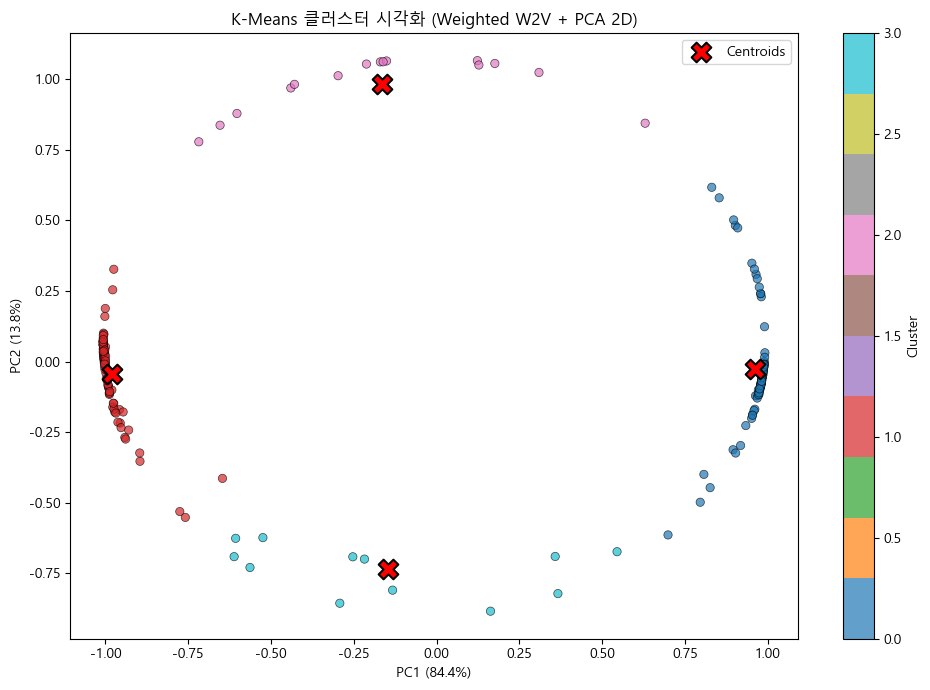


=== 카테고리 × 클러스터 교차표 ===
cluster    0   1   2   3  All
category                     
뉴진스       20  13  15   2   50
월드컵       36  11   0   2   49
이스라엘      16  28   0   6   50
인공지능      16  30   0   2   48
All       88  82  15  12  197

=== 카테고리별 클러스터 비율 ===
cluster       0      1    2      3
category                          
뉴진스       0.400  0.260  0.3  0.040
월드컵       0.735  0.224  0.0  0.041
이스라엘      0.320  0.560  0.0  0.120
인공지능      0.333  0.625  0.0  0.042


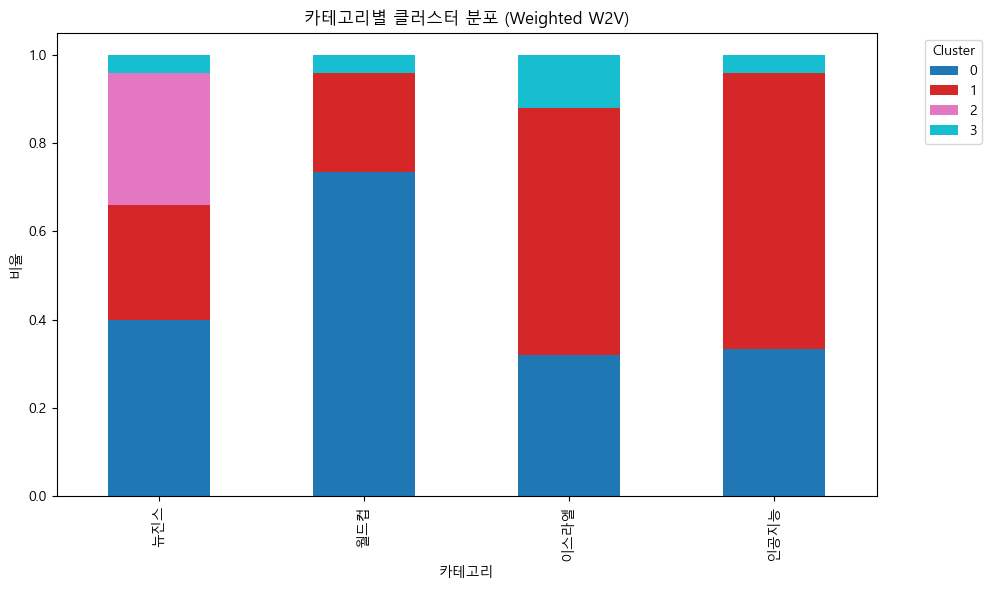

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# [기존 6번 대체] K-Means 모델 학습
# ==========================================
print("K-Means 클러스터링 및 최적 k 탐색 중...")

K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # centered 대신 normalized 벡터 사용!
    km.fit(video_vectors_normalized) 
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(video_vectors_normalized, km.labels_))

best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(video_vectors_normalized) # 여기도 normalized 사용

video_df['cluster'] = kmeans.labels_

# ==========================================
# 7. 클러스터별 상위 키워드 추출 (Word2Vec 공간 역산)
# ==========================================
print("\n=== 클러스터별 대표 키워드 ===")
for i in range(best_k):
    # 1. 영점 조절된 공간의 중심점 가져오기
    centered_centroid = kmeans.cluster_centers_[i]
    
    # 2. 중심점을 원래 Word2Vec 공간으로 복원 (global_mean 다시 더하기)
    original_centroid = centered_centroid + global_mean
    
    # 3. Word2Vec 모델에서 복원된 중심점과 가장 가까운 단어 추출
    similar_words = w2v_model.wv.similar_by_vector(original_centroid, topn=10)
    top_keywords = [word for word, sim in similar_words]
    
    print(f'클러스터 {i}: {", ".join(top_keywords)}')

# ==========================================
# [기존 8번 대체] PCA 2D 시각화
# ==========================================
print("\nPCA 시각화 생성 중...")
pca = PCA(n_components=2, random_state=42)

# PCA에도 normalized 벡터를 입력하여 축소!
coords = pca.fit_transform(video_vectors_normalized)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=kmeans.labels_, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('K-Means 클러스터 시각화 (Weighted W2V + PCA 2D)')

# 클러스터 중심점 시각화
centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='k', linewidths=1.5, label='Centroids'
)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 9. 카테고리별 클러스터 분포 분석 (교차표)
# ==========================================
print("\n=== 카테고리 × 클러스터 교차표 ===")
cross = pd.crosstab(video_df['category'], video_df['cluster'], margins=True)
print(cross)

print('\n=== 카테고리별 클러스터 비율 ===')
cross_pct = pd.crosstab(video_df['category'], video_df['cluster'], normalize='index')
print(cross_pct.round(3))

# 시각화: 스택 바 차트
cross_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title('카테고리별 클러스터 분포 (Weighted W2V)')
plt.xlabel('카테고리')
plt.ylabel('비율')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()